In [71]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

import scanpy as sc
from dmt import DyMoTree

adata = sc.read_h5ad("../data/bench/lt/day246/anndata/anndata.h5ad")
#adata = sc.read_h5ad('../data/bench/mmE/anndata/anndata.h5ad')
#adata.obsm['X_emb_new'] = adata.obsm['X_emb'][:,:50]
dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='Undifferentiated',
               terminal=['Neutrophil','Monocyte'],
               lineage_col='Cell.type.annotation',
               emb_key='emb',
               device='cuda',
               seed=1024)

dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

Successfully loaded state: Undifferentiated, cells: 1509
Successfully loaded state: Neutrophil, cells: 996
Successfully loaded state: Monocyte, cells: 1004
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Undifferentiated' (Edges: 73941)
[*] Intra-state graph built for 'Neutrophil' (Edges: 48804)
[*] Intra-state graph built for 'Monocyte' (Edges: 49196)
[*] Calculating composite similarity between progenitor 'Undifferentiated' and terminals ['Neutrophil', 'Monocyte']...
[*] Inter-state graph built for 'Neutrophil' (Edges: 414452)
[*] Inter-state graph built for 'Monocyte' (Edges: 454401)


In [75]:
dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-4},
              iter = {'formal':300,
                    'intra':100,
                    'lineage':200},
              sample_ratio = 256,
              alpha = 0)

:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for Undifferentiated ::


100%|██████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.14it/s, loss=0.69]


:: Do pre-train Graph encoder for Neutrophil ::


100%|█████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.46it/s, loss=0.653]


:: Do pre-train Graph encoder for Monocyte ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 200/200 : 100%|█████████████████████████████████| 200/200 [00:32<00:00,  6.25it/s, loss=0.534]


:: DyMoTree Training::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [00:48<00:00,  6.13it/s, loss=0.889]

[2026-04-14 17:24:00] get fate space of Undifferentiated


<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

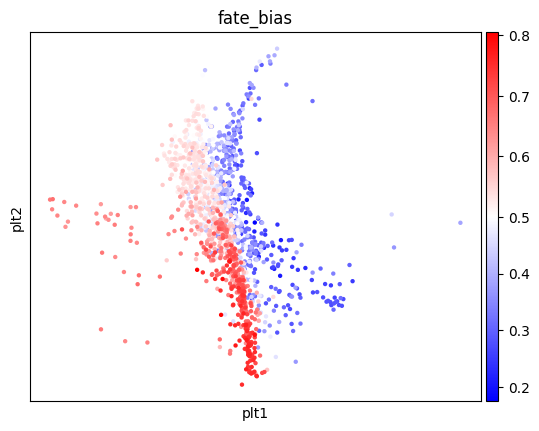

In [78]:
progenitor = dmt.treedata.get_node('Undifferentiated',adata_object=True)
progenitor.obsm['X_plt'] = progenitor.obs.loc[:,['SPRING.x','SPRING.y']].values
progenitor.obs['fate_bias'] = dmt.cal_fate_bias(progenitor.obs['Neutrophil_fate'], progenitor.obs['Monocyte_fate'])
sc.pl.embedding(progenitor, basis='plt', color=['fate_bias'], show=False,cmap='bwr',vcenter=0.5,size=40)

In [79]:
from utils.metrics import calculate_fate_metrics

truth_fate = progenitor.obs['ground_truth'].values
predict_fate = 1-progenitor.obs['fate_bias'].values

calculate_fate_metrics(truth_fate, 
                           predict_fate, 
                           threshold = 0.5)

{'auroc': 0.8318538437982872,
 'acc': 0.7594433399602386,
 'f1': 0.7586594615552378,
 'pearson': 0.5943280253224427,
 'spearman': 0.6009068561808565}

In [72]:
# find cell state
dmt.find_state(n_state=3,
               n_pca=5,
               n_diff=5,
               n_gene=10,
               method='spearman')

[2026-04-10 18:15:47] find cell state of ICM
[2026-04-10 18:15:47] Filtering Data by fate space


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[2026-04-10 18:15:50] PCA transformation
[2026-04-10 18:15:51] Run Diffusion map
[2026-04-10 18:15:52] Find archetypes


<Axes: title={'center': 'Fate_State'}, xlabel='plt1', ylabel='plt2'>

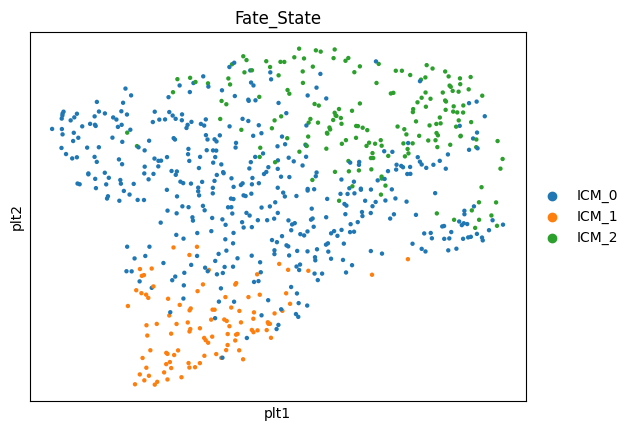

In [73]:
hspc = dmt.treedata.get_node('ICM',adata_object=True)
#hspc.obsm['X_spring'] = hspc.obs.loc[:,['SPRING.x','SPRING.y']].values
#hspc.obs['fate_bias'] = dmt.cal_fate_bias(hspc.obs['Neutrophil_fate'], hspc.obs['Monocyte_fate'])
sc.pl.embedding(hspc, basis='plt', color=['Fate_State'], show=False,cmap='bwr',vcenter=0.5,size=40)

[<Axes: xlabel='Fate State', ylabel='PrE_fate'>,
 <Axes: xlabel='Fate State', ylabel='EPI_fate'>]

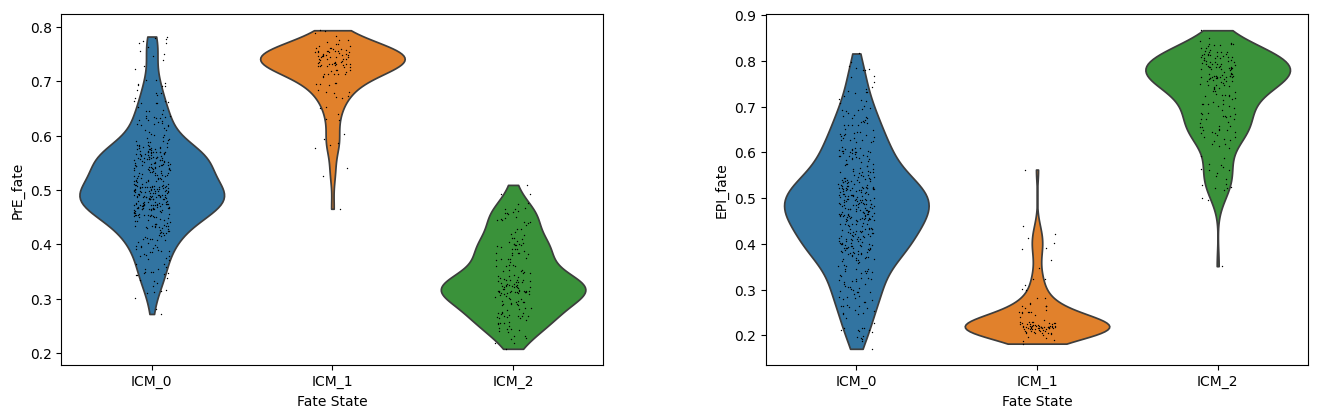

In [74]:
sc.pl.violin(hspc, keys=['PrE_fate', 'EPI_fate'], groupby='Fate_State', show=False)

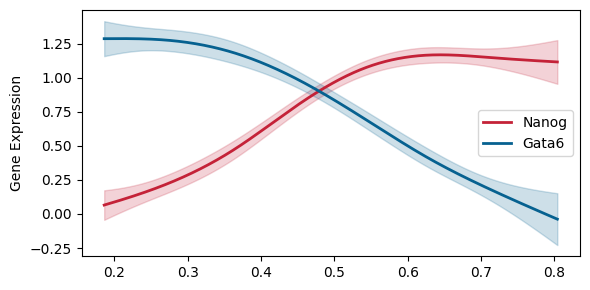

In [33]:
from utils.plotting import plot_feature_trend
features = ['Nanog','Gata6']
color_map = {features[0]:"#c42238",features[1]:"#066190"}
ax = plot_feature_trend(progenitor,'fate_bias',features,color_map,lin_space=1000,n_splines=10,lam=10,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(6, 3))

In [38]:
import pandas as pd
from scipy.stats import entropy
import numpy as np
prob_values = progenitor.obs[['PrE_fate', 'EPI_fate']].values/progenitor.obs[['PrE_fate', 'EPI_fate']].values.sum(axis=1,keepdims=True)
progenitor.obs['Stemness_score_DyMoTree'] = entropy(prob_values, axis=1, base=2)
progenitor.obs['development_time_DyMoTree'] = 1-entropy(prob_values, axis=1, base=2)

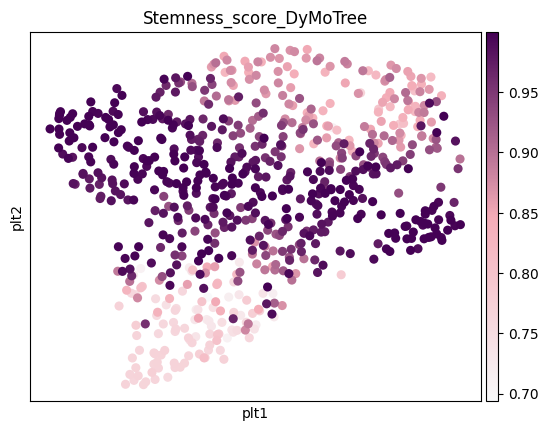

In [47]:
import matplotlib.colors as mcolors
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#f8f9fa"), (0.5,"#f4acb7"),(1,'#440154')]
)
sc.pl.embedding(progenitor,basis='plt',color='Stemness_score_DyMoTree',cmap=custom_bwr)

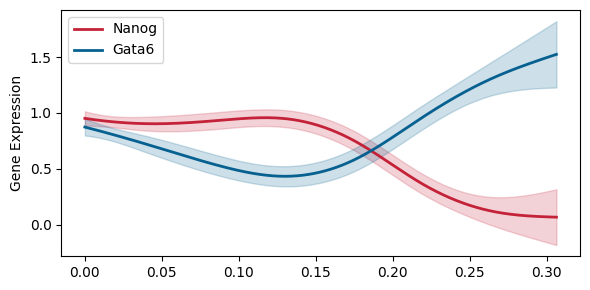

In [44]:
from utils.plotting import plot_feature_trend
features = ['Nanog','Gata6']
color_map = {features[0]:"#c42238",features[1]:"#066190"}
ax = plot_feature_trend(progenitor,'development_time_DyMoTree',features,color_map,lin_space=1000,n_splines=10,lam=10,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(6, 3))